## CHECK BASLINE MONTEL BEFORE FEATURE SELCTION

In [1]:
#import modules 
import pandas as pd
import numpy as np
from typing import List
from rdkit import Chem
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors

RANDOM_STATE = 42

label_case = 'label_cutoff_20%' # label_cutoff_50%, label_cutoff_20%

In [2]:
df = pd.read_csv('../Data/mordred_descriptors_without_NaN.csv')
descriptors_df = df.drop(columns=['SMILES'])
display(df.head())

,SMILES,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,Nc1ccc(S(=O)(=O)Nc2ncccn2)cc1,13.093540,11.115492,0,0,21.139069,2.370239,4.740478,21.139069,1.243475,...,9.645817,49.622129,250.052447,9.261202,536,23,86.0,97.0,5.895833,3.708333
1,Nc1nc(Cl)nc2c1ncn2C1OC(CO)C(O)C1F,15.710828,14.057406,0,0,25.397628,2.520227,4.881224,25.397628,1.269881,...,10.082679,70.336447,303.053445,9.775918,753,34,110.0,135.0,7.500000,4.361111
2,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1,13.202929,11.709699,0,0,20.712705,2.383498,4.742568,20.712705,1.218394,...,9.663770,63.242131,253.052112,9.037575,535,22,88.0,100.0,6.506944,3.625000
3,c1ccc(CC2=NCCN2)cc1,9.192388,8.248586,0,2,15.982234,2.246428,4.436582,15.982234,1.331853,...,8.907477,55.114662,160.100048,6.670835,209,11,58.0,64.0,2.722222,2.750000
4,CN1C(=O)CCC1c1cccnc1,9.996954,9.253985,0,0,16.886871,2.383381,4.647225,16.886871,1.298990,...,9.339525,58.137510,176.094963,7.043799,238,17,66.0,77.0,4.194444,2.916667


In [3]:
all_sheets = pd.read_excel('..//Data/hob_data_set.xlsx', sheet_name=None)
train = all_sheets['Training set']

# Check the SMILES column name in both dataframes
print("descriptors_df SMILES column:", df.columns[0])
print("train SMILES column:", train.columns[1])
print()

# Merge on SMILES
merged_df = df.merge(train[['smile', 'label_cutoff_50%', 'label_cutoff_20%']], 
                                  left_on='SMILES', 
                                  right_on='smile', 
                                  how='inner')

print(f"Original descriptors_df: {descriptors_df.shape[0]} molecules")
print(f"After merge: {merged_df.shape[0]} molecules")

descriptors_df SMILES column: SMILES
train SMILES column: smile

Original descriptors_df: 1157 molecules
After merge: 1157 molecules


In [4]:
# Βήμα 1 — Εντόπισε τα μόρια με NaN στο label_cutoff_20%
nan_mask_20 = merged_df['label_cutoff_20%'].isna()
print(f"Μόρια με NaN στο label_cutoff_20%: {nan_mask_20.sum()}")

# Βήμα 2 — Αφαίρεσε τα από το descriptors_df και το merged_df
descriptors_df_clean = descriptors_df[~nan_mask_20.values].reset_index(drop=True)
merged_df_clean = merged_df[~nan_mask_20].reset_index(drop=True)
descriptors_df_clean['SMILES'] = merged_df_clean['SMILES']

print(f"Μόρια πριν: {len(descriptors_df)}")
print(f"Μόρια μετά: {len(descriptors_df_clean)}")
print(f"\ny_train_50 — High: {merged_df_clean['label_cutoff_50%'].sum()}, Low: {(merged_df_clean['label_cutoff_50%']==0).sum()}")
print(f"y_train_20 — High: {merged_df_clean['label_cutoff_20%'].sum()}, Low: {(merged_df_clean['label_cutoff_20%']==0).sum()}")

Μόρια με NaN στο label_cutoff_20%: 15
Μόρια πριν: 1157
Μόρια μετά: 1142

y_train_50 — High: 621, Low: 521
y_train_20 — High: 859.0, Low: 283


In [5]:
merged_df_clean

,SMILES,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,...,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,smile,label_cutoff_50%,label_cutoff_20%
0,Nc1ccc(S(=O)(=O)Nc2ncccn2)cc1,13.093540,11.115492,0,0,21.139069,2.370239,4.740478,21.139069,1.243475,...,9.261202,536,23,86.0,97.0,5.895833,3.708333,Nc1ccc(S(=O)(=O)Nc2ncccn2)cc1,1,1.0
1,Nc1nc(Cl)nc2c1ncn2C1OC(CO)C(O)C1F,15.710828,14.057406,0,0,25.397628,2.520227,4.881224,25.397628,1.269881,...,9.775918,753,34,110.0,135.0,7.500000,4.361111,Nc1nc(Cl)nc2c1ncn2C1OC(CO)C(O)C1F,1,1.0
2,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1,13.202929,11.709699,0,0,20.712705,2.383498,4.742568,20.712705,1.218394,...,9.037575,535,22,88.0,100.0,6.506944,3.625000,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1,1,1.0
3,c1ccc(CC2=NCCN2)cc1,9.192388,8.248586,0,2,15.982234,2.246428,4.436582,15.982234,1.331853,...,6.670835,209,11,58.0,64.0,2.722222,2.750000,c1ccc(CC2=NCCN2)cc1,1,1.0
4,CN1C(=O)CCC1c1cccnc1,9.996954,9.253985,0,0,16.886871,2.383381,4.647225,16.886871,1.298990,...,7.043799,238,17,66.0,77.0,4.194444,2.916667,CN1C(=O)CCC1c1cccnc1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,Clc1cccc(Cl)c1NC1=NCCN1,10.744501,9.870405,0,3,17.881594,2.335590,4.651027,17.881594,1.277257,...,9.957276,301,17,70.0,80.0,4.444444,3.138889,Clc1cccc(Cl)c1NC1=NCCN1,1,1.0
1138,N=C(N)N=C(O)Cc1c(Cl)cccc1Cl,11.072670,10.311148,0,3,17.507310,2.318438,4.636876,17.507310,1.167154,...,10.208844,384,19,70.0,77.0,6.805556,3.388889,N=C(N)N=C(O)Cc1c(Cl)cccc1Cl,1,1.0
1139,CN(C(=O)C(Cl)Cl)c1ccc(O)cc1,10.325124,9.704472,0,0,16.814625,2.307250,4.614501,16.814625,1.201045,...,10.130480,312,19,66.0,74.0,6.555556,3.166667,CN(C(=O)C(Cl)Cl)c1ccc(O)cc1,1,1.0
1140,O=P([O-])([O-])C(Cl)(Cl)P(=O)(O)O,8.152948,8.723360,4,0,10.363081,2.449490,4.898979,10.363081,0.942098,...,18.605497,136,18,56.0,64.0,8.187500,2.125000,O=P([O-])([O-])C(Cl)(Cl)P(=O)(O)O,0,0.0


In [6]:
# Το hold-out split ορίστηκε στο preprocess_data. Κάθε βήμα επιλογής παρακάτω
# χρησιμοποιεί μόνο τα training μόρια, ώστε το test set να μείνει ανέγγιχτο.
train_smiles = pd.read_csv('../Data/train_smiles.csv')['SMILES']
train_mask = merged_df_clean['SMILES'].isin(train_smiles).values

print(f"Train molecules: {train_mask.sum()}")
print(f"Test molecules:  {(~train_mask).sum()}")

Train molecules: 913
Test molecules:  229


In [7]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

# Φόρτωσε το dataset χωρίς NaN (πριν feature selection)
df_full = pd.read_csv('../Data/mordred_descriptors_without_NaN.csv')
print(f"df_full αρχικό shape: {df_full.shape}")

# Φιλτράρισμα με βάση τα SMILES των training μορίων
smiles_col = 'SMILES' if 'SMILES' in df_full.columns else 'smile'
valid_smiles = merged_df_clean.loc[train_mask, 'SMILES'].values
df_full_filtered = df_full[df_full[smiles_col].isin(valid_smiles)].reset_index(drop=True)
print(f"df_full μετά φιλτράρισμα: {df_full_filtered.shape}")

# Features και target
cols_to_drop = [c for c in ['SMILES', 'smile'] if c in df_full_filtered.columns]
X_full = df_full_filtered.drop(columns=cols_to_drop)
y = merged_df_clean.loc[train_mask, label_case].astype(int).values

print(f"X_full shape: {X_full.shape}")
print(f"y shape: {y.shape}")

# Scaling
scaler_full = RobustScaler()
X_full_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_full),
    columns=X_full.columns
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
}

cb_full = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=100,
    auto_class_weights='Balanced'
)

print("\nTraining CatBoost με όλους τους descriptors...")
cv_results = cross_validate(cb_full, X_full_scaled, y, cv=cv, scoring=scoring)

print(f"\n=== CatBoost πριν το feature selection ===")
for metric in scoring.keys():
    mean = np.mean(cv_results[f'test_{metric}'])
    std = np.std(cv_results[f'test_{metric}'], ddof=1)
    print(f"{metric:<22} {mean:.3f} ± {std:.3f}")

df_full αρχικό shape: (1157, 1673)
df_full μετά φιλτράρισμα: (913, 1673)
X_full shape: (913, 1672)
y shape: (913,)

Training CatBoost με όλους τους descriptors...
0:	learn: 0.6811372	total: 394ms	remaining: 3m 16s
100:	learn: 0.2609383	total: 18.3s	remaining: 1m 12s
200:	learn: 0.0921413	total: 37.2s	remaining: 55.4s
300:	learn: 0.0355150	total: 54.9s	remaining: 36.3s
400:	learn: 0.0171658	total: 1m 13s	remaining: 18.3s
499:	learn: 0.0105944	total: 1m 32s	remaining: 0us
0:	learn: 0.6809370	total: 197ms	remaining: 1m 38s
100:	learn: 0.2719815	total: 17.6s	remaining: 1m 9s
200:	learn: 0.0977471	total: 35.4s	remaining: 52.7s
300:	learn: 0.0379523	total: 55s	remaining: 36.4s
400:	learn: 0.0192190	total: 1m 12s	remaining: 17.9s
499:	learn: 0.0118079	total: 1m 29s	remaining: 0us
0:	learn: 0.6806966	total: 195ms	remaining: 1m 37s
100:	learn: 0.2810311	total: 18s	remaining: 1m 11s
200:	learn: 0.0942529	total: 35.5s	remaining: 52.8s
300:	learn: 0.0346309	total: 53s	remaining: 35.1s
400:	learn: 

## FEATURE SELECTION

## Variance Threshold

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Separate SMILES from numeric descriptors
smiles_col = descriptors_df_clean['SMILES']
X = descriptors_df_clean.drop(columns=['SMILES'])

# Apply variance threshold - removes constant/near-constant descriptors. 
# Applyinng a thershold of 0.01 to avoid removing descriptors that are important but have low variance
selector = VarianceThreshold(threshold=0.01)
selector.fit(X[train_mask])

# Identify which columns survived and which were removed
kept_mask = selector.get_support()
kept_cols = X.columns[kept_mask].tolist()
removed_cols = X.columns[~kept_mask].tolist()

print(f"Descriptors before: {X.shape[1]}")
print(f"Descriptors removed (low variance): {len(removed_cols)}")
print(f"Descriptors remaining: {len(kept_cols)}")

descriptors_df_clean = descriptors_df_clean[['SMILES'] + kept_cols]
print(f"New shape: {descriptors_df_clean.shape}")

Descriptors before: 1672
Descriptors removed (low variance): 323
Descriptors remaining: 1349
New shape: (1142, 1350)


## Correlation Analysis

In [9]:
import numpy as np

# Work on numeric descriptors only, training molecules only
X = descriptors_df_clean.loc[train_mask].drop(columns=['SMILES'])

# Compute absolute correlation matrix
corr_matrix = X.corr().abs()

# Take the upper triangle only (avoid double-counting pairs and self-correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Count how many descriptors would be dropped at different thresholds
for threshold in [0.99, 0.95, 0.90, 0.85, 0.80]:
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f"Threshold {threshold}: would remove {len(to_drop)} descriptors, keeping {X.shape[1] - len(to_drop)}")

Threshold 0.99: would remove 392 descriptors, keeping 957
Threshold 0.95: would remove 666 descriptors, keeping 683
Threshold 0.9: would remove 775 descriptors, keeping 574
Threshold 0.85: would remove 910 descriptors, keeping 439
Threshold 0.8: would remove 1012 descriptors, keeping 337


In [10]:
X = descriptors_df_clean.loc[train_mask].drop(columns=['SMILES'])
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Pick the threshold to inspect
threshold = 0.95

# For each descriptor that would be dropped, find what it correlates with
to_drop_details = {}
for col in upper.columns:
    correlated_with = upper.index[upper[col] > threshold].tolist()
    if correlated_with:
        # Show the highest correlation partner and the value
        max_partner = upper[col].idxmax()
        max_val = upper[col].max()
        to_drop_details[col] = (max_partner, round(max_val, 4))

print(f"Descriptors flagged at threshold {threshold}: {len(to_drop_details)}\n")

# Print first 40 as a sample
for i, (col, (partner, val)) in enumerate(list(to_drop_details.items())[:40]):
    print(f"{col:20s} ↔ {partner:20s} (r = {val})")

Descriptors flagged at threshold 0.95: 666

ABCGG                ↔ ABC                  (r = 0.984)
SpAbs_A              ↔ ABC                  (r = 0.9964)
SpDiam_A             ↔ SpMax_A              (r = 0.9682)
SpAD_A               ↔ SpAbs_A              (r = 1.0)
LogEE_A              ↔ SpAbs_A              (r = 0.9526)
VE3_A                ↔ LogEE_A              (r = 0.9893)
VR2_A                ↔ VR1_A                (r = 0.9975)
nAromBond            ↔ nAromAtom            (r = 0.9981)
nHeavyAtom           ↔ ABC                  (r = 0.9969)
nH                   ↔ nAtom                (r = 0.9672)
nC                   ↔ SpAbs_A              (r = 0.9506)
ATS1dv               ↔ ATS0dv               (r = 0.9652)
ATS2dv               ↔ ATS0dv               (r = 0.9725)
ATS3dv               ↔ ATS2dv               (r = 0.9636)
ATS4dv               ↔ ATS3dv               (r = 0.9773)
ATS5dv               ↔ ATS4dv               (r = 0.9735)
ATS6dv               ↔ ATS5dv               (r =

In [ ]:
import numpy as np
from scipy import stats

X = descriptors_df_clean.loc[train_mask].drop(columns=['SMILES'])
target = merged_df_clean.loc[train_mask, label_case].values

# Correlation of each descriptor with the target (for tie-breaking)
target_corr = {}
for col in X.columns:
    corr, _ = stats.pointbiserialr(target, X[col])
    target_corr[col] = abs(corr) if np.isfinite(corr) else 0.0

# Absolute correlation matrix, upper triangle
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.95
to_drop = set()

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > threshold:
            # Of the redundant pair, drop whichever is LESS correlated with target,
            # unless one of them has already been removed
            if row in to_drop or col in to_drop:
                continue
            if target_corr[row] >= target_corr[col]:
                to_drop.add(col)
            else:
                to_drop.add(row)
to_drop = list(to_drop)
print(f"Descriptors to remove: {len(to_drop)}")

# Apply the removal
descriptors_df_clean = descriptors_df_clean.drop(columns=to_drop, errors='ignore')
print(f"Remaining shape: {descriptors_df_clean.shape}")

Descriptors to remove: 628
Remaining shape: (1142, 722)


In [12]:
#  Save descriptors after correlation removal
descriptors_df_clean.to_csv(f'../Data/descriptors_after_correlation_{label_case}.csv', index=False)
print(f"Saved: {descriptors_df_clean.shape}")

Saved: (1142, 722)


Calculating Mutual Information...

=== Mutual Information Summary ===
Total descriptors: 721
MI = 0 (zero information):    209
MI > 0 (some information):    512
MI > 0.01:                    325
MI > 0.05:                    16
MI > 0.10:                    0

Top 20 most informative descriptors:
descriptor  MI_score
  BCUTp-1l  0.076760
 PEOE_VSA1  0.071785
  BCUTs-1h  0.070077
  BCUTv-1l  0.069754
   SM1_Dzv  0.069718
 BCUTdv-1l  0.062904
  BCUTm-1h  0.059211
 BCUTpe-1h  0.057271
    Mor08m  0.056450
 PEOE_VSA9  0.055860
 BCUTdv-1h  0.053042
    ATSC1s  0.051726
    Mor04p  0.051087
     Xc-5d  0.050734
   TopoPSA  0.050595
    Mor31p  0.050330
   MDEO-11  0.049201
      Vabc  0.048768
    ATSC0c  0.048412
     WPSA2  0.047628


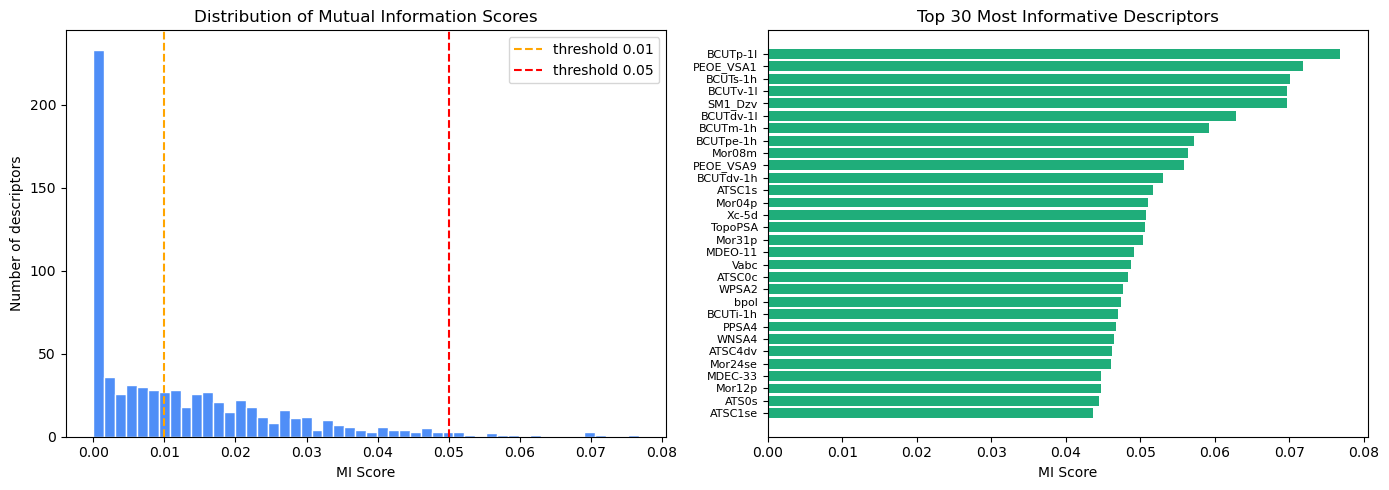

In [13]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = descriptors_df_clean.loc[train_mask].drop(columns=['SMILES'])
y = merged_df_clean.loc[train_mask, label_case].values

# Calculate Mutual Information
print("Calculating Mutual Information...")
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)

# Create ranked dataframe
mi_df = pd.DataFrame({
    'descriptor': X.columns,
    'MI_score': mi_scores
}).sort_values('MI_score', ascending=False).reset_index(drop=True)

# Summary
print(f"\n=== Mutual Information Summary ===")
print(f"Total descriptors: {len(mi_df)}")
print(f"MI = 0 (zero information):    {(mi_df['MI_score'] == 0).sum()}")
print(f"MI > 0 (some information):    {(mi_df['MI_score'] > 0).sum()}")
print(f"MI > 0.01:                    {(mi_df['MI_score'] > 0.01).sum()}")
print(f"MI > 0.05:                    {(mi_df['MI_score'] > 0.05).sum()}")
print(f"MI > 0.10:                    {(mi_df['MI_score'] > 0.10).sum()}")

print(f"\nTop 20 most informative descriptors:")
print(mi_df.head(20).to_string(index=False))

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
axes[0].hist(mi_df['MI_score'], bins=50, color='#4f8ef7', edgecolor='white')
axes[0].set_xlabel('MI Score')
axes[0].set_ylabel('Number of descriptors')
axes[0].set_title('Distribution of Mutual Information Scores')
axes[0].axvline(x=0.01, color='orange', linestyle='--', label='threshold 0.01')
axes[0].axvline(x=0.05, color='red', linestyle='--', label='threshold 0.05')
axes[0].legend()

# Right: top 30 descriptors
top30 = mi_df.head(30)
axes[1].barh(range(30), top30['MI_score'].values[::-1], color='#1fad7a')
axes[1].set_yticks(range(30))
axes[1].set_yticklabels(top30['descriptor'].values[::-1], fontsize=8)
axes[1].set_xlabel('MI Score')
axes[1].set_title('Top 30 Most Informative Descriptors')

plt.tight_layout()
plt.savefig(f'mutual_information_{label_case}.png', dpi=150, bbox_inches='tight')
plt.show()

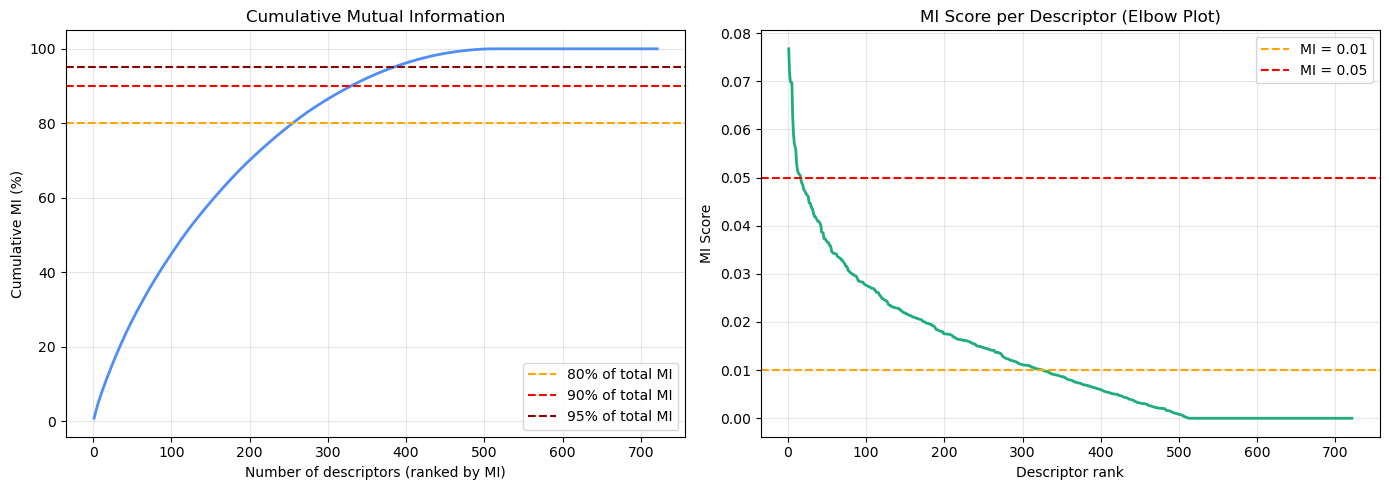

80% of total MI captured by top 255 descriptors
90% of total MI captured by top 330 descriptors
95% of total MI captured by top 384 descriptors


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Sort by MI score descending (already done)
mi_sorted = mi_df.sort_values('MI_score', ascending=False).reset_index(drop=True)

# Cumulative MI
mi_sorted['cumulative_MI'] = mi_sorted['MI_score'].cumsum()
mi_sorted['cumulative_MI_pct'] = mi_sorted['cumulative_MI'] / mi_sorted['MI_score'].sum() * 100
mi_sorted['rank'] = range(1, len(mi_sorted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cumulative MI %
axes[0].plot(mi_sorted['rank'], mi_sorted['cumulative_MI_pct'], 
             color='#4f8ef7', linewidth=2)
axes[0].axhline(y=80, color='orange', linestyle='--', label='80% of total MI')
axes[0].axhline(y=90, color='red', linestyle='--', label='90% of total MI')
axes[0].axhline(y=95, color='darkred', linestyle='--', label='95% of total MI')
axes[0].set_xlabel('Number of descriptors (ranked by MI)')
axes[0].set_ylabel('Cumulative MI (%)')
axes[0].set_title('Cumulative Mutual Information')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: MI score per descriptor (zoomed to show elbow)
axes[1].plot(mi_sorted['rank'], mi_sorted['MI_score'], 
             color='#1fad7a', linewidth=2)
axes[1].axhline(y=0.01, color='orange', linestyle='--', label='MI = 0.01')
axes[1].axhline(y=0.05, color='red', linestyle='--', label='MI = 0.05')
axes[1].set_xlabel('Descriptor rank')
axes[1].set_ylabel('MI Score')
axes[1].set_title('MI Score per Descriptor (Elbow Plot)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'cumulative_mi_{label_case}.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key numbers
for pct in [80, 90, 95]:
    n = (mi_sorted['cumulative_MI_pct'] <= pct).sum() + 1
    print(f"{pct}% of total MI captured by top {n} descriptors")

## CATBOOST FOR FEATURE SELECTION

In [15]:
import catboost
print(catboost.__version__)

1.2.10


In [ ]:
from catboost import CatBoostClassifier
import pandas as pd

# Προετοιμασία δεδομένων
X = descriptors_df_clean.loc[train_mask].drop(columns=['SMILES'])
y = merged_df_clean.loc[train_mask, label_case].values
# Εκπαίδευση CatBoost για feature importance
print("Training CatBoost...")
if label_case == 'label_cutoff_50%':
    class_weights = [1, 1]  # Balanced for 50% cutoff
elif label_case == 'label_cutoff_20%':
    class_weights = [1, 4]  # Adjusted for 20% cutoff
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=100,
    class_weights=class_weights
)
cb_model.fit(X, y)
# Feature importance
cb_importance = pd.DataFrame({
    'descriptor': X.columns,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f"\nTop 20 descriptors:")
print(cb_importance.head(20).to_string(index=False))
print(f"\nDescriptors with importance > 0: {(cb_importance['importance'] > 0).sum()}")

Training CatBoost...
0:	learn: 0.6413020	total: 125ms	remaining: 1m 2s
100:	learn: 0.1747185	total: 8.53s	remaining: 33.7s
200:	learn: 0.1369318	total: 16.4s	remaining: 24.4s
300:	learn: 0.1101471	total: 24.7s	remaining: 16.3s
400:	learn: 0.0902654	total: 33.1s	remaining: 8.16s
499:	learn: 0.0727482	total: 41.2s	remaining: 0us

Top 20 descriptors:
descriptor  importance
     MID_X    1.432760
   ATSC1se    1.194427
   MAXaasC    0.924489
    NssssN    0.861653
  MINssssN    0.856635
     NdssC    0.811867
    Mor23m    0.809498
    GATS1m    0.742027
    Mor24m    0.741487
    MATS4c    0.693326
    GATS6Z    0.684456
     VR2_A    0.674311
     C1SP2    0.668437
    GATS2i    0.647165
    Mor13m    0.646067
     ZMIC3    0.607338
     DPSA3    0.606956
    AATS8i    0.575346
    SssCH2    0.567861
      CIC4    0.565858

Descriptors with importance > 0: 628


=== Αποτελέσματα Τομής ===
MI top-400:              400
CatBoost top-400:        400
Κοινοί (τομή):           232
Μόνο στο MI:             168
Μόνο στο CatBoost:       168

Top 20 κοινοί descriptors (ταξινομημένοι κατά μέσο rank):
descriptor  mi_rank  cb_rank  avg_rank
   ATSC1se       30        2      15.0
     DPSA3       35       17      25.0
 BCUTpe-1h        8       49      27.5
      TPSA       38       23      29.5
  BCUTv-1l        4       58      30.0
   ATSC4dv       25       40      31.5
     ZMIC3       49       16      31.5
   SM1_DzZ       40       29      33.5
      CIC4       53       20      35.5
    Mor04p       13       65      38.0
     DPSA4       36       46      40.0
    ATSC1s       12       76      43.0
    SssCH2       76       19      46.5
 ETA_eta_F       54       43      47.5
     NdssC       94        6      49.0
    Xc-3dv       41       63      51.0
    ATSC0c       19       87      52.0
   MDEO-11       17       92      53.5
    Mor24m      111        9

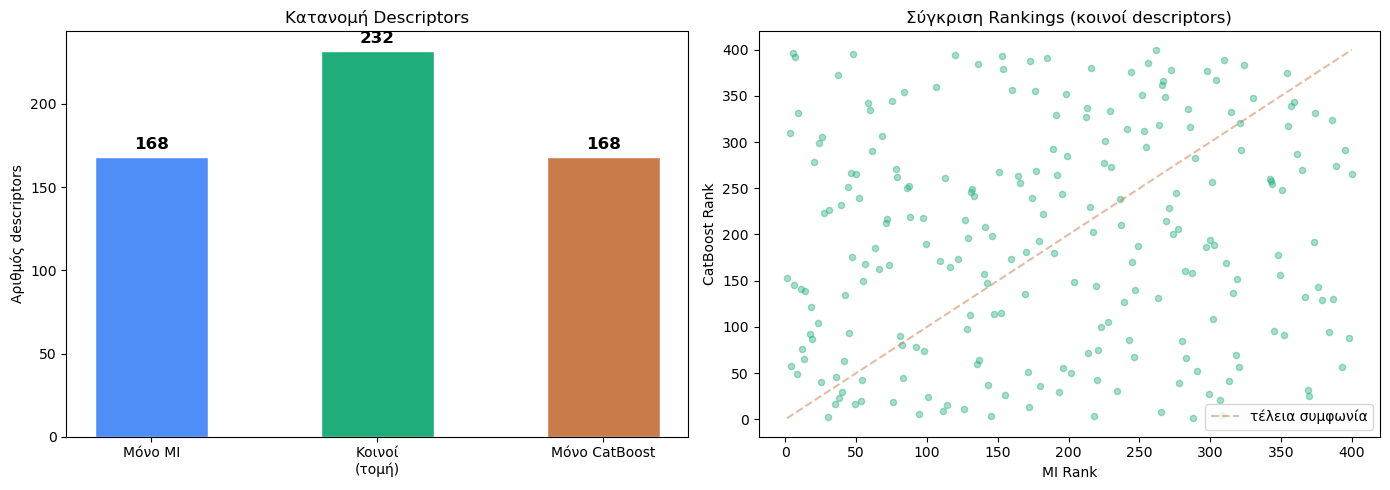

In [17]:
import matplotlib.pyplot as plt

# Top-400 από MI (ήδη υπάρχει από πριν)
mi_top400 = set(mi_df.head(400)['descriptor'].tolist())

# Top-400 από CatBoost
cb_top400 = set(cb_importance.head(400)['descriptor'].tolist())

# Τομή
intersection = mi_top400 & cb_top400
mi_only = mi_top400 - cb_top400
cb_only = cb_top400 - mi_top400

print(f"=== Αποτελέσματα Τομής ===")
print(f"MI top-400:              {len(mi_top400)}")
print(f"CatBoost top-400:        {len(cb_top400)}")
print(f"Κοινοί (τομή):           {len(intersection)}")
print(f"Μόνο στο MI:             {len(mi_only)}")
print(f"Μόνο στο CatBoost:       {len(cb_only)}")

# Venn-style visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart σύγκρισης
categories = ['Μόνο MI', 'Κοινοί\n(τομή)', 'Μόνο CatBoost']
values = [len(mi_only), len(intersection), len(cb_only)]
colors = ['#4f8ef7', '#1fad7a', '#C97B4A']
bars = axes[0].bar(categories, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Κατανομή Descriptors')
axes[0].set_ylabel('Αριθμός descriptors')

# Top-20 κοινοί — ποιοι έχουν υψηλό rank και στις δύο μεθόδους
mi_ranks = {row['descriptor']: idx for idx, row in mi_df.iterrows()}
cb_ranks = {row['descriptor']: idx for idx, row in cb_importance.iterrows()}

common_list = []
for d in intersection:
    common_list.append({
        'descriptor': d,
        'mi_rank': mi_ranks[d] + 1,
        'cb_rank': cb_ranks[d] + 1,
        'avg_rank': (mi_ranks[d] + cb_ranks[d]) / 2
    })

common_df = pd.DataFrame(common_list).sort_values('avg_rank')
print(f"\nTop 20 κοινοί descriptors (ταξινομημένοι κατά μέσο rank):")
print(common_df.head(20).to_string(index=False))

# Scatter plot ranks
axes[1].scatter(
    [mi_ranks[d]+1 for d in intersection],
    [cb_ranks[d]+1 for d in intersection],
    alpha=0.4, color='#1fad7a', s=20
)
axes[1].set_xlabel('MI Rank')
axes[1].set_ylabel('CatBoost Rank')
axes[1].set_title('Σύγκριση Rankings (κοινοί descriptors)')
axes[1].plot([1, 400], [1, 400], '--', color='#C97B4A', alpha=0.5, label='τέλεια συμφωνία')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'intersection_analysis_{label_case}.png', dpi=150, bbox_inches='tight')
plt.show()

## DEFINE 2D AND 3D DESCRIPTORS

In [18]:
from mordred import Calculator, descriptors

# Ορισμός final_features από την τομή που υπολογίσαμε
final_features = sorted(intersection)   # σταθερή σειρά στηλών σε κάθε εκτέλεση
print(f"Τελικό feature set: {len(final_features)} descriptors")

# Δημιουργία calculator για metadata
calc = Calculator(descriptors)

# Χαρτογράφηση descriptor → 2D ή 3D
descriptor_dims = {}
for desc in calc.descriptors:
    name = str(desc)
    descriptor_dims[name] = '3D' if desc.require_3D else '2D'

# Κατηγοριοποίηση
dim_results = []
for d in final_features:
    dim = descriptor_dims.get(d, 'Unknown')
    dim_results.append({'descriptor': d, 'type': dim})

dim_df = pd.DataFrame(dim_results)

print("=== 2D vs 3D στους τελικούς descriptors ===")
print(dim_df['type'].value_counts())
print(f"\n2D descriptors: {(dim_df['type']=='2D').sum()}")
print(f"3D descriptors: {(dim_df['type']=='3D').sum()}")
print(f"Unknown: {(dim_df['type']=='Unknown').sum()}")

Τελικό feature set: 232 descriptors
=== 2D vs 3D στους τελικούς descriptors ===
type
2D    183
3D     49
Name: count, dtype: int64

2D descriptors: 183
3D descriptors: 49
Unknown: 0


## SAVE THE DATASET FROM FEATURES SELECTION

In [19]:
from openpyxl import load_workbook

# Sheet 1: Dataset (μόρια × descriptors) — όλα τα μόρια, train και test
X_final = descriptors_df_clean[final_features].copy()

#Save Merged DF
merged_df_clean.to_csv(f'../Data/merged_df_clean_{label_case}.csv', index=False)

# Sheet 2: Metadata (descriptor | type)
with pd.ExcelWriter(f'../Data/final_dataset_{label_case}.xlsx', engine='openpyxl') as writer:
    X_final.to_excel(writer, sheet_name='Dataset', index=False)
    dim_df.to_excel(writer, sheet_name='Metadata', index=False)

print(f"Saved: {X_final.shape}")

Saved: (1142, 232)
